In [ ]:
!pip install imgaug

In [ ]:
import cv2
import numpy as np
import warnings
warnings.filterwarnings('ignore')
!pip install tf-keras-vis tensorflow imgaug numpy==1.26.0

def label_to_numpy(labels):
  final_labels = np.zeros((len(labels), 4))
  for i in range(len(labels)):
    label = labels[i]
    if label == 'Attentive':
      final_labels[i,:] = np.array([1, 0, 0, 0])
    if label == 'DrinkingCoffee':
      final_labels[i,:] = np.array([0, 1, 0, 0])
    if label == 'UsingMirror':
      final_labels[i,:] = np.array([0, 0, 1, 0])
    if label == 'UsingRadio':
      final_labels[i,:] = np.array([0, 0, 0, 1])
  return final_labels

def augment(data, augmenter):
  if len(data.shape) == 3:
    return augmenter.augment_image(data)
  if len(data.shape) == 4:
    return augmenter.augment_images(data)

def rotate(data, rotate):
  fun = augmenters.Affine(rotate = rotate)
  return augment(data, fun)

def shear(data, shear):
  fun = augmenters.Affine(shear = shear)
  return augment(data, fun)

def scale(data, scale):
  fun = augmenters.Affine(scale = shear)
  return augment(data, fun)

def flip_left_right(data):
  fun = augmenters.Fliplr()
  return augment(data, fun)

def flip_up_down(data):
  fun = augmenters.Flipud()
  return augment(data, fun)

def remove_color(data, channel):
  new_data = data.copy()
  if len(data.shape) == 3:
    new_data[:,:,channel] = 0
    return new_data
  if len(data.shape) == 4:
    new_data[:,:,:,channel] = 0
    return new_data

class pkg:
  #### DOWNLOADING AND LOADING DATA
  def get_metadata(metadata_path, which_splits = ['train', 'test']):
    '''returns metadata dataframe which contains columns of:
       * index: index of data into numpy data
       * class: class of image
       * split: which dataset split is this a part of?
    '''
    metadata = pd.read_csv(metadata_path)
    keep_idx = metadata['split'].isin(which_splits)
    metadata = metadata[keep_idx]

    # Get dataframes for each class.
    df_coffee_train = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'train')]
    df_coffee_test = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'test')]
    df_mirror_train = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'train')]
    df_mirror_test = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'test')]
    df_attentive_train = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'train')]
    df_attentive_test = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'test')]
    df_radio_train = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'train')]
    df_radio_test = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'test')]

    # Get number of items in class with lowest number of images.
    num_samples_train = min(df_coffee_train.shape[0], \
                            df_mirror_train.shape[0], \
                            df_attentive_train.shape[0], \
                            df_radio_train.shape[0])
    num_samples_test = min(df_coffee_test.shape[0], \
                            df_mirror_test.shape[0], \
                            df_attentive_test.shape[0], \
                            df_radio_test.shape[0])

    # Resample each of the classes and concatenate the images.
    metadata_train = pd.concat([df_coffee_train.sample(num_samples_train), \
                          df_mirror_train.sample(num_samples_train), \
                          df_attentive_train.sample(num_samples_train), \
                          df_radio_train.sample(num_samples_train) ])
    metadata_test = pd.concat([df_coffee_test.sample(num_samples_test), \
                          df_mirror_test.sample(num_samples_test), \
                          df_attentive_test.sample(num_samples_test), \
                          df_radio_test.sample(num_samples_test) ])

    metadata = pd.concat( [metadata_train, metadata_test] )

    return metadata

  def get_data_split(split_name, flatten, all_data, metadata, image_shape):
    '''
    returns images (data), labels from folder of format [image_folder]/[split_name]/[class_name]/
    flattens if flatten option is True
    '''
    # Get dataframes for each class.
    df_coffee_train = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'train')]
    df_coffee_test = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'test')]
    df_mirror_train = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'train')]
    df_mirror_test = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'test')]
    df_attentive_train = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'train')]
    df_attentive_test = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'test')]
    df_radio_train = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'train')]
    df_radio_test = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'test')]

    # Get number of items in class with lowest number of images.
    num_samples_train = min(df_coffee_train.shape[0], \
                            df_mirror_train.shape[0], \
                            df_attentive_train.shape[0], \
                            df_radio_train.shape[0])
    num_samples_test = min(df_coffee_test.shape[0], \
                            df_mirror_test.shape[0], \
                            df_attentive_test.shape[0], \
                            df_radio_test.shape[0])

    # Resample each of the classes and concatenate the images.
    metadata_train = pd.concat([df_coffee_train.sample(num_samples_train), \
                          df_mirror_train.sample(num_samples_train), \
                          df_attentive_train.sample(num_samples_train), \
                          df_radio_train.sample(num_samples_train) ])
    metadata_test = pd.concat([df_coffee_test.sample(num_samples_test), \
                          df_mirror_test.sample(num_samples_test), \
                          df_attentive_test.sample(num_samples_test), \
                          df_radio_test.sample(num_samples_test) ])

    metadata = pd.concat( [metadata_train, metadata_test] )

    sub_df = metadata[metadata['split'].isin([split_name])]
    index  = sub_df['index'].values
    labels = sub_df['class'].values
    data = all_data[index,:]
    if flatten:
      data = data.reshape([-1, np.product(image_shape)])
    return data, labels

  def get_train_data(flatten, all_data, metadata, image_shape):
    return get_data_split('train', flatten, all_data, metadata, image_shape)

  def get_test_data(flatten, all_data, metadata, image_shape):
    return get_data_split('test', flatten, all_data, metadata, image_shape)

  def get_field_data(flatten, all_data, metadata, image_shape):
    return get_data_split('field', flatten, all_data, metadata, image_shape)

class helpers:
  #### PLOTTING
  def plot_image(data, num_ims, figsize=(8,6), labels = [], index = None, image_shape = [64,64,3]):
    '''
    if data is a single image, display that image

    if data is a 4d stack of images, display that image
    '''
    print(data.shape)
    num_dims   = len(data.shape)
    num_labels = len(labels)

    # reshape data if necessary
    if num_dims == 1:
      data = data.reshape(target_shape)
    if num_dims == 2:
      data = data.reshape(-1,image_shape[0],image_shape[1],image_shape[2])
    num_dims   = len(data.shape)

    # check if single or multiple images
    if num_dims == 3:
      if num_labels > 1:
        print('Multiple labels does not make sense for single image.')
        return

      label = labels
      if num_labels == 0:
        label = ''
      image = data

    if num_dims == 4:
      image = data[index, :]
      label = labels[index]

    # plot image of interest

    nrows=int(np.sqrt(num_ims))
    ncols=int(np.ceil(num_ims/nrows))
    print(nrows,ncols)
    count=0
    if nrows==1 and ncols==1:
      print('Label: %s'%label)
      plt.imshow(image)
      plt.show()
    else:
      print(labels)
      fig = plt.figure(figsize=figsize)
      for i in range(nrows):
        for j in range(ncols):
          if count<num_ims:
            fig.add_subplot(nrows,ncols,count+1)
            plt.imshow(image[count])
            count+=1
      fig.set_size_inches(18.5, 10.5)
      plt.show()



  #### QUERYING AND COMBINING DATA
  def get_misclassified_data(data, labels, predictions):
    '''
    Gets the data and labels that are misclassified in a classification task
    Returns:
    -missed_data
    -missed_labels
    -predicted_labels (corresponding to missed_labels)
    -missed_index (indices of items in original dataset)
    '''
    missed_index     = np.where(np.abs(predictions.squeeze() - labels.squeeze()) > 0)[0]
    missed_labels    = labels[missed_index]
    missed_data      = data[missed_index,:]
    predicted_labels = predictions[missed_index]
    return missed_data, missed_labels, predicted_labels, missed_index

  def combine_data(data_list, labels_list):
    return np.concatenate(data_list, axis = 0), np.concatenate(labels_list, axis = 0)

  def model_to_string(model):
    import re
    stringlist = []
    model.summary(print_fn=lambda x: stringlist.append(x))

    for layer in model.layers:
      if hasattr(layer,"activation"):
        stringlist.append(str(layer.activation))

    sms = "\n".join(stringlist)
    sms = re.sub('r_\d\d\d','', sms)
    sms = re.sub('r_\d\d','', sms)
    sms = re.sub('r_\d','', sms)
    return sms

  def plot_acc(history, ax = None, xlabel = 'Epoch #'):
    hist = history.history

    if 'val_accuracy' in hist:
      num_epochs = len(hist['val_accuracy'])
    else:
      num_epochs = len(hist['accuracy'])

    hist['epoch'] = list(range(num_epochs))

    df = pd.DataFrame.from_dict(hist)

    if 'val_accuracy' in df:
          best_epoch = df.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']
    else:
      best_epoch = df.sort_values(by = 'accuracy', ascending = False).iloc[0]['epoch']


    if ax is None:
      f, ax = plt.subplots(1,1)
    if 'val_accuracy' in df:
      sns.lineplot(x = 'epoch', y = 'val_accuracy', data = df, label = 'Validation', ax = ax)
    sns.lineplot(x = 'epoch', y = 'accuracy', data = df, label = 'Training', ax = ax)

    ax.axhline(0.25, linestyle = '--',color='red', label = 'Chance')
    ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')

    ax.legend(loc = 1)
    ax.set_ylim([0.01, 1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy (Fraction)')

    plt.show()

class models:
  def DenseClassifier(hidden_layer_sizes, nn_params, dropout = 0.5):
    model = Sequential()
    model.add(Flatten(input_shape = nn_params['input_shape']))
    for ilayer in hidden_layer_sizes:
      model.add(Dense(ilayer, activation = 'relu'))
      if dropout:
        model.add(Dropout(dropout))
    model.add(Dense(units = nn_params['output_neurons'], activation = nn_params['output_activation']))
    model.compile(loss=nn_params['loss'],
                  optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.95),
                  metrics=['accuracy'])
    return model

  def CNNClassifier(num_hidden_layers, nn_params, dropout = 0.5):
    model = Sequential()

    model.add(Conv2D(32, (3, 3), input_shape=nn_params['input_shape'], padding = 'same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    for i in range(num_hidden_layers-1):
        model.add(Conv2D(32, (3, 3), padding = 'same'))
        model.add(Activation('relu'))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(units = 128, activation = 'relu'))
    model.add(Dropout(dropout))

    model.add(Dense(units = 64, activation = 'relu'))


    model.add(Dense(units = nn_params['output_neurons'], activation = nn_params['output_activation']))

    # initiate RMSprop optimizer
    opt = tensorflow.keras.optimizers.RMSprop(learning_rate=1e-4)

    # Let's train the model using RMSprop
    model.compile(loss=nn_params['loss'],
                  optimizer=opt,
                  metrics=['accuracy'])
    return model

  def TransferClassifier(name, nn_params, trainable = True):
    expert_dict = {'VGG16': VGG16,
                   'VGG19': VGG19,
                   'ResNet50':ResNet50,
                   'DenseNet121':DenseNet121}

    expert_conv = expert_dict[name](weights = 'imagenet',
                                              include_top = False,
                                              input_shape = nn_params['input_shape'])
    for layer in expert_conv.layers:
      layer.trainable = trainable

    expert_model = Sequential()
    expert_model.add(expert_conv)
    expert_model.add(GlobalAveragePooling2D())

    expert_model.add(Dense(128, activation = 'relu'))
    expert_model.add(Dropout(0.3))

    expert_model.add(Dense(64, activation = 'relu'))

    expert_model.add(Dense(nn_params['output_neurons'], activation = nn_params['output_activation']))

    expert_model.compile(loss = nn_params['loss'],
                  optimizer = optimizers.SGD(learning_rate=1e-4, momentum=0.95),
                  metrics=['accuracy'])

    return expert_model

<>:259: SyntaxWarning: invalid escape sequence '\d'
<>:260: SyntaxWarning: invalid escape sequence '\d'
<>:261: SyntaxWarning: invalid escape sequence '\d'
<>:259: SyntaxWarning: invalid escape sequence '\d'
<>:260: SyntaxWarning: invalid escape sequence '\d'
<>:261: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3157040241.py:259: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('r_\d\d\d','', sms)
/tmp/ipython-input-3157040241.py:260: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('r_\d\d','', sms)
/tmp/ipython-input-3157040241.py:261: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('r_\d','', sms)


In [ ]:
%%writefile pkg.py
import numpy as np
import pandas as pd

def get_metadata(metadata_path, which_splits=['train','test','field']):
    """
    Loads metadata CSV and returns a balanced dataframe
    with columns: index, class, split
    """

    metadata = pd.read_csv(metadata_path)
    metadata = metadata[metadata['split'].isin(which_splits)]

    # group by class + split
    groups = []
    for cls in ['Attentive','DrinkingCoffee','UsingMirror','UsingRadio']:
        for split in which_splits:
            df = metadata[(metadata['class']==cls) & (metadata['split']==split)]
            if len(df) > 0:
                groups.append(df)

    # balance each split separately
    balanced_groups = []
    for split in which_splits:
        split_groups = [g for g in groups if g['split'].iloc[0] == split]
        if len(split_groups) == 0:
            continue
        min_count = min(g.shape[0] for g in split_groups)
        for g in split_groups:
            balanced_groups.append(g.sample(min_count, random_state=0))

    return pd.concat(balanced_groups).reset_index(drop=True)


def get_data_split(split_name, flatten, all_data, metadata, image_shape):
    """
    Returns (X, y_strings)
    X: images
    y_strings: list of class names
    """

    sub_df = metadata[metadata['split'] == split_name]
    indices = sub_df['index'].values
    labels  = sub_df['class'].values
    X = all_data[indices]

    if flatten:
        X = X.reshape(len(X), -1)

    return X, labels


def get_train_data(flatten, all_data, metadata, image_shape):
    return get_data_split('train', flatten, all_data, metadata, image_shape)

def get_test_data(flatten, all_data, metadata, image_shape):
    return get_data_split('test', flatten, all_data, metadata, image_shape)

def get_field_data(flatten, all_data, metadata, image_shape):
    return get_data_split('field', flatten, all_data, metadata, image_shape)

Overwriting pkg.py


In [ ]:
%%writefile helpers.py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_image(data, num_ims, figsize=(8,6), labels=[], index=None, image_shape=(64,64,3)):
    """
    Display images from a numpy array.
    """

    data = np.array(data)

    # reshape single image
    if len(data.shape) == 1:
        data = data.reshape(image_shape)

    # reshape flattened images
    if len(data.shape) == 2:
        data = data.reshape((-1, *image_shape))

    if len(data.shape) == 3:
        plt.figure(figsize=figsize)
        plt.imshow(data)
        plt.axis('off')
        return

    images = data
    n = num_ims
    rows = int(np.sqrt(n))
    cols = int(np.ceil(n/rows))

    plt.figure(figsize=figsize)
    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx < n:
                plt.subplot(rows, cols, idx+1)
                plt.imshow(images[idx])
                plt.axis('off')
                idx += 1

    plt.show()


def model_to_string(model):
    """
    Converts Keras model summary into a string.
    """
    lines = []
    model.summary(print_fn=lines.append)
    return "\n".join(lines)


def plot_acc(history):
    """
    Plot training and validation accuracy curves.
    """
    hist = pd.DataFrame(history.history)
    hist['epoch'] = range(len(hist))

    if 'val_accuracy' in hist:
      best_epoch = hist['val_accuracy'].idxmax()
    else:
      best_epoch = hist['accuracy'].idxmax()

    plt.figure(figsize=(8,5))
    sns.lineplot(data=hist, x='epoch', y='accuracy', label='Training')
    if 'val_accuracy' in hist:
      sns.lineplot(data=hist, x='epoch', y='val_accuracy', label='Validation')

    plt.axhline(0.25, linestyle='--', color='red', label='Chance')
    plt.axvline(best_epoch, linestyle='--', color='green', label='Best Epoch')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (Fraction)")
    plt.ylim(0, 1)
    plt.legend(loc='best')
    plt.show()


def get_misclassified_data(model, X_test, y_true, class_names):
    """
    Returns indices + (pred_label, true_label, image)
    """
    preds = model.predict(X_test)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.array([class_names.index(c) for c in y_true])

    mis_idx = np.where(pred_classes != true_classes)[0]

    return [
        {
            'index': i,
            'pred': class_names[pred_classes[i]],
            'true': y_true[i],
            'image': X_test[i]
        }
        for i in mis_idx
    ]


def combine_data(X, y):
    """
    Zips X and y into tuples.
    """
    return list(zip(X, y))

Overwriting helpers.py


In [ ]:
%%writefile models.py
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, GlobalAveragePooling2D
import tensorflow.keras.optimizers as optimizers
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, DenseNet121

# ---------- DENSE NN ----------
def DenseClassifier(hidden_layer_sizes, nn_params):
    """
    Fully connected classifier on flattened images.
    """
    model = Sequential()
    model.add(Flatten(input_shape=nn_params['input_shape']))

    for size in hidden_layer_sizes:
        model.add(Dense(size, activation='relu'))

    model.add(Dense(nn_params['output_neurons'], activation=nn_params['output_activation']))

    model.compile(
        loss=nn_params['loss'],
        optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.95),
        metrics=['accuracy']
    )
    return model


# ---------- SIMPLE CNN ----------
def CNNClassifier(num_hidden_layers, nn_params):
    """
    A simple CNN with Conv -> Pool repeated.
    """
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=nn_params['input_shape']))
    model.add(MaxPooling2D((2,2)))

    for _ in range(num_hidden_layers - 1):
        model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
        model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(nn_params['output_neurons'], activation=nn_params['output_activation']))

    model.compile(
        loss=nn_params['loss'],
        optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.95),
        metrics=['accuracy']
    )
    return model


# ---------- TRANSFER LEARNING ----------
def TransferClassifier(name, nn_params):
    """
    Transfer learning classifier using ImageNet backbone.
    """

    backbones = {
        'VGG16': VGG16,
        'VGG19': VGG19,
        'ResNet50': ResNet50,
        'DenseNet121': DenseNet121
    }

    base = backbones[name](weights='imagenet', include_top=False, input_shape=nn_params['input_shape'])

    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dropout(0.3),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(nn_params['output_neurons'], activation=nn_params['output_activation'])
    ])

    model.compile(
        loss=nn_params['loss'],
        optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.95),
        metrics=['accuracy']
    )
    return model

Overwriting models.py


In [ ]:
import zipfile

import os
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import pkg
import helpers
import models

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import model_selection

from collections import Counter

import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, MaxPooling2D, Dropout, Flatten, Reshape, Dense, Conv2D, GlobalAveragePooling2D

import tensorflow.keras.optimizers as optimizers
from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.applications import VGG16, VGG19, ResNet50, DenseNet121

from imgaug import augmenters

### defining project variables
# file variables
# image_data_url       = 'https://drive.google.com/uc?id=1qmTuUyn0525-612yS-wkp8gHB72Wv_XP'
# metadata_url         = 'https://drive.google.com/uc?id=1OfKnq3uIT29sXjWSZqOOpceig8Ul24OW'
image_data_path      = './image_data.npy'
metadata_path        = './metadata.csv'
image_shape          = (64, 64, 3)

# neural net parameters
nn_params = {}
nn_params['input_shape']       = image_shape
nn_params['output_neurons']    = 4
nn_params['loss']              = 'categorical_crossentropy'
nn_params['output_activation'] = 'softmax'

###
!wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Driver%20Distraction%20Detection/metadata.csv'
!wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Driver%20Distraction%20Detection/image_data.npy'

### pre-loading all data of interest
_all_data = np.load('image_data.npy')
_metadata = pkg.get_metadata(metadata_path, ['train','test','field'])

### preparing definitions
# downloading and loading data
get_data_split = pkg.get_data_split
get_metadata    = lambda :                 pkg.get_metadata(metadata_path, ['train','test'])
get_train_data  = lambda flatten = False : pkg.get_train_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)
get_test_data   = lambda flatten = False : pkg.get_test_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)
get_field_data  = lambda flatten = False : pkg.get_field_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)

# plotting
plot_image = lambda data, num_ims,figsize=(8,6), labels = [], index = None: helpers.plot_image(data = data, num_ims=num_ims, figsize=figsize,labels = labels, index = index, image_shape = image_shape);
plot_acc       = lambda history: helpers.plot_acc(history)

# querying and combining data
model_to_string        = lambda model: helpers.model_to_string(model)
get_misclassified_data = helpers.get_misclassified_data;
combine_data           = helpers.combine_data;

# models with input parameters
DenseClassifier     = lambda hidden_layer_sizes: models.DenseClassifier(hidden_layer_sizes = hidden_layer_sizes, nn_params = nn_params);
CNNClassifier       = lambda num_hidden_layers: models.CNNClassifier(num_hidden_layers, nn_params = nn_params);
TransferClassifier  = lambda name: models.TransferClassifier(name = name, nn_params = nn_params);

#monitor = ModelCheckpoint('./model.h5', monitor='val_accuracy', verbose=0, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')
monitor = ModelCheckpoint('./model.keras', monitor='val_accuracy', verbose=0, save_best_only=True, save_weights_only=False, mode='auto')

metadata.csv.1      100%[===================>] 200.33K  --.-KB/s    in 0.001s  
image_data.npy.1    100%[===================>] 423.61M   164MB/s    in 2.6s    


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.4039 - loss: 1.3416 - val_accuracy: 0.3250 - val_loss: 1.3559
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7861 - loss: 0.9278 - val_accuracy: 0.3152 - val_loss: 1.6932
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9124 - loss: 0.6213 - val_accuracy: 0.3087 - val_loss: 1.8919
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9433 - loss: 0.4338 - val_accuracy: 0.3630 - val_loss: 1.9546
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9523 - loss: 0.3195 - val_accuracy: 0.2957 - val_loss: 2.5316
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9662 - loss: 0.2379 - val_accuracy: 0.3500 - val_loss: 2.5485
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9679 - loss: 0.1979 - val_accuracy: 0.3120 - val_loss: 2.7871
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9703 - loss: 0.1651 - val_accuracy: 

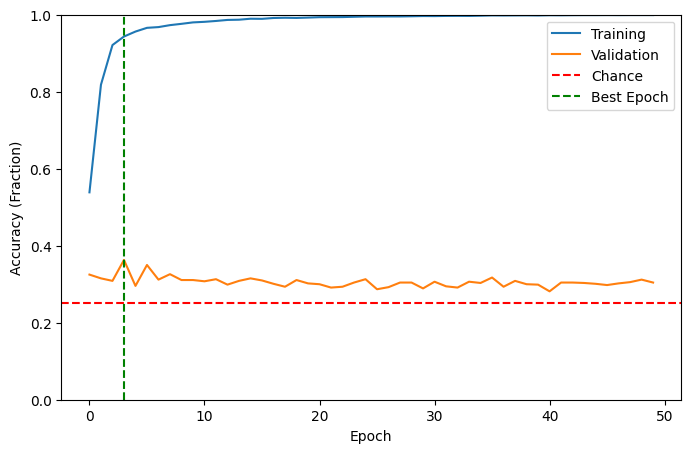

CNN


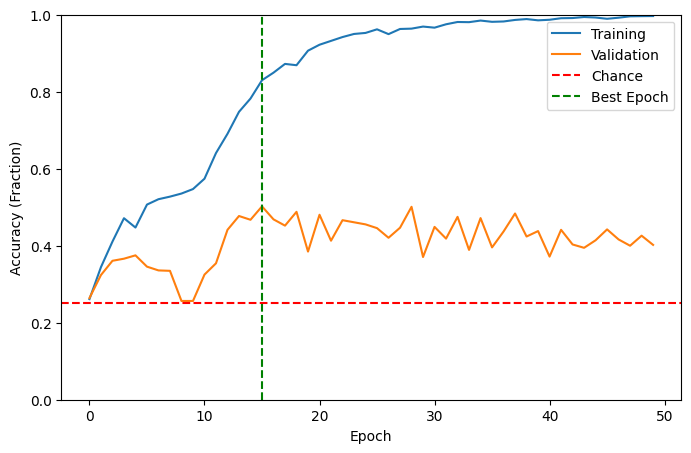

In [ ]:
train_data, train_labels = get_train_data(flatten=True)
test_data, test_labels = get_test_data(flatten=True)

train_data = train_data.reshape([-1, 64, 64, 3])
test_data = test_data.reshape([-1, 64, 64, 3])

# save string versions of labels
train_labels_strings = train_labels
test_labels_strings = test_labels

# convert labels into numpy vectors (one-hot encoding!)
train_labels = label_to_numpy(train_labels)
test_labels = label_to_numpy(test_labels)

dense = models.DenseClassifier(hidden_layer_sizes = (128,64), nn_params=nn_params)
cnn = models.CNNClassifier(num_hidden_layers = 5, nn_params=nn_params)

dense.fit(train_data, train_labels, epochs = 50, validation_data = (test_data, test_labels), shuffle = True, callbacks = [monitor])
cnn.fit(train_data, train_labels, epochs = 50, validation_data = (test_data, test_labels), shuffle = True, callbacks = [monitor])

print('Dense')
plot_acc(dense.history)

print('CNN')
plot_acc(cnn.history)

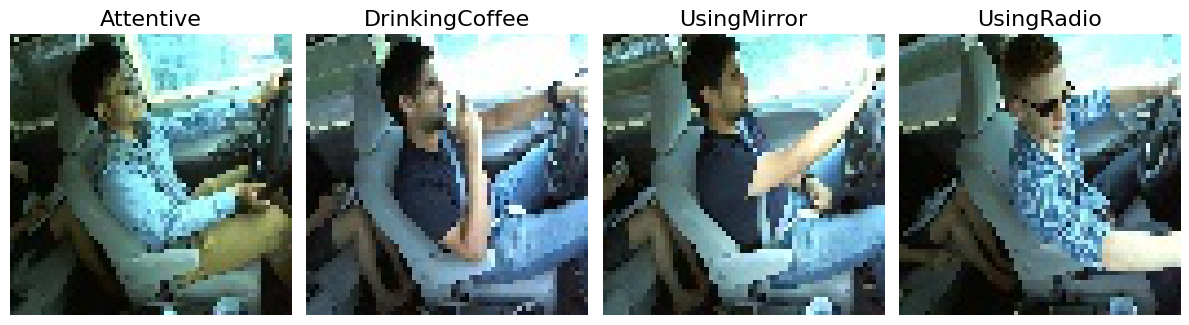

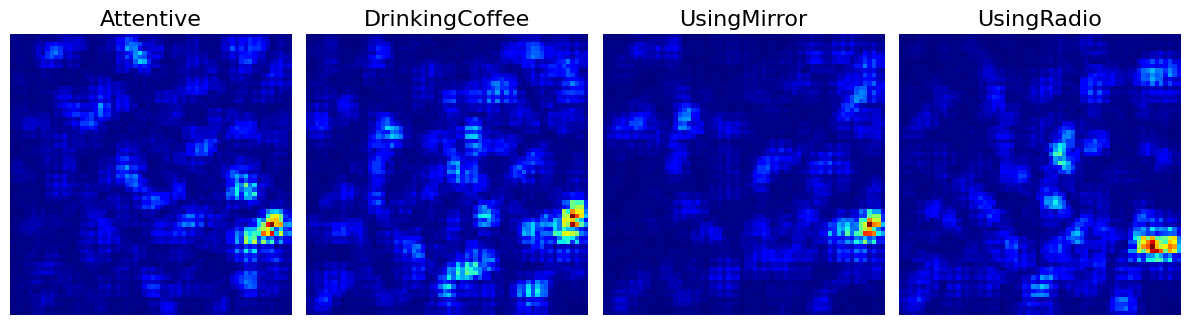

In [ ]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import backend as K
from matplotlib import pyplot as plt
from matplotlib import cm
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.scorecam import Scorecam
from tf_keras_vis.activation_maximization import ActivationMaximization
from tf_keras_vis.activation_maximization.callbacks import Progress
from tf_keras_vis.activation_maximization.input_modifiers import Jitter, Rotate2D
from tf_keras_vis.activation_maximization.regularizers import TotalVariation2D, Norm
from tf_keras_vis.utils.model_modifiers import ExtractIntermediateLayer, ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

X_train, y_train_str = get_train_data(flatten=True)
X_test, y_test_str = get_test_data(flatten=True)

X_train = X_train.reshape([-1, 64, 64, 3])
X_test = X_test.reshape([-1, 64, 64, 3])

# save string versions of labels
y_train = y_train_str
y_test = y_test_str

# convert labels into numpy vectors (one-hot encoding!)
y_train = label_to_numpy(y_train)
y_test = label_to_numpy(y_test)

images = []
for i, title in enumerate(y_test_str):
  dim = (64, 64)
  img = np.array(cv2.resize(X_test[i], dim))
  images.append(img)
images = np.asarray(images)

def getImageSamples():
  image_samples = []
  image_samples_labels = []
  idx = random.randint(0, 230)
  for i in range(4):
    image_samples.append(images[idx])
    image_samples_labels.append(y_test_str[idx])
    idx = idx + 230
  image_samples = np.asarray(image_samples)
  return image_samples, image_samples_labels

def plot_vanilla_saliency_of_a_model(model, X_input, image_titles):
    score = CategoricalScore(list(range(X_input.shape[0])))

    # Create Saliency visualization object
    saliency = Saliency(model, clone=True)

    # Generate saliency map
    saliency_map = saliency(score, X_input)

    # Rendering
    f, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 4))
    for i, title in enumerate(image_titles):
        ax[i].set_title(title, fontsize=16)
        ax[i].imshow(X_input[i])
        ax[i].axis('off')
    plt.tight_layout()
    plt.show()

    # Plot saliencies
    f, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 4))
    for i, title in enumerate(image_titles):
        ax[i].set_title(title, fontsize=16)
        ax[i].imshow(saliency_map[i], cmap='jet')
        ax[i].axis('off')
    plt.tight_layout()
    plt.show()
imgs, imgs_labels = getImageSamples()
plot_vanilla_saliency_of_a_model(cnn, imgs, imgs_labels)

In [ ]:
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, MaxPooling2D, Dropout, Flatten, Reshape, Dense, Conv2D, GlobalAveragePooling2D
import tensorflow.keras.optimizers as optimizers
from tensorflow.keras.applications.vgg16 import VGG16

# get data
train_data, train_labels = get_train_data(flatten=True)
test_data, test_labels = get_test_data(flatten=True)

train_data = train_data.reshape([-1, 64, 64, 3])
test_data = test_data.reshape([-1, 64, 64, 3])

# save string versions of labels
train_labels_strings = train_labels
test_labels_strings = test_labels

# convert labels into numpy vectors (one-hot encoding!)
train_labels = label_to_numpy(train_labels)
test_labels = label_to_numpy(test_labels)

from tensorflow.keras.applications.vgg16 import VGG16

# load the vgg network that is an 'expert' at 'imagenet' but do not include the FC layers
vgg_expert = VGG16(weights = 'imagenet', include_top = False, input_shape = (64, 64, 3))

# we add the first 12 layers of vgg to our own model vgg_model
vgg_model = Sequential()
vgg_model.add(vgg_expert)

# and then add our own layers on top of it
vgg_model.add(GlobalAveragePooling2D())
vgg_model.add(Dense(1024, activation = 'relu'))
vgg_model.add(Dropout(0.3))
vgg_model.add(Dense(512, activation = 'relu'))
vgg_model.add(Dropout(0.3))
vgg_model.add(Dense(4, activation = 'softmax'))

# finally, we build the vgg model and turn it on so we can use it!
vgg_model.compile(loss = 'categorical_crossentropy',
          optimizer = optimizers.SGD(learning_rate=1e-4, momentum=0.95),
          metrics=['accuracy'])

# grab our augmented training manual
# and hand it to our model to train
vgg_model.fit(train_data, train_labels, epochs = 10, validation_data = (test_data, test_labels), shuffle = True)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.3858 - loss: 1.2702 - val_accuracy: 0.6315 - val_loss: 0.8089
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9506 - loss: 0.1613 - val_accuracy: 0.5707 - val_loss: 1.2545
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.9742 - loss: 0.0844 - val_accuracy: 0.7326 - val_loss: 1.0024
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.9884 - loss: 0.0396 - val_accuracy: 0.6652 - val_loss: 1.1333
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9926 - loss: 0.0243 - val_accuracy: 0.6467 - val_loss: 1.1658
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9947 - loss: 0.0210 - val_accuracy: 0.7033 - val_loss: 1.1491
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9884 - loss: 0.0340 - val_accuracy: 0.7739 - val_loss: 1.0737
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9976 - loss: 0.0089 - 

In [ ]:
predictions = vgg_model.predict(test_data)
predictions = np.argmax(predictions,axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [ ]:
predictions = np.argmax(vgg_model.predict(test_data), axis=-1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
# First, convert the 4 labels to 2 numbers.
# If the true label is 'Attentive', then we add 0 (for attentive) to final_labels. Otherwise,
# for all other labels, we add a label of 1 (for distracted). Hint: .append() will add an element to a list!
final_labels = []
for label in test_labels_strings:
  ### FILL IN THIS LOOP ###
  if(label == 'Attentive'):
    final_labels.append(0)
  else:
    final_labels.append(1)
# Now, we change our final predictions to 0 and 1. That is, if the prediction
# currently is 0, then add 0 (for attentive) to binary_predictions. Otherwise,
# add 1 (for distracted).
binary_predictions = []
for label in predictions:
  ### FILL IN THIS LOOP ###
  if(label == 0):
    binary_predictions.append(0)
  else:
    binary_predictions.append(1)
print('Accuracy is %d %%'%(accuracy_score(final_labels, binary_predictions)*100.0))

Accuracy is 85 %


In [ ]:
confusion = confusion_matrix(final_labels, binary_predictions)
print(confusion)

tp  = confusion[1][1]
tn  = confusion[0][0]
fp = confusion[0][1]
fn = confusion[1][0]

print('True positive: %d'%tp)
print('True negative: %d'%tn)
print('False positive: %d'%fp)
print('False negative: %d'%fn)

[[131  99]
 [ 35 655]]
True positive: 655
True negative: 131
False positive: 99
False negative: 35


In [ ]:
# grab our plotting package
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion, annot = True, fmt = 'd', cbar_kws={'label':'count'});
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [ ]:
precision = tp/(tp+fp)
recall = tp/(tp+fn)
print(precision)
print(recall)